# Load data (step 0)

In [2]:
import json, os
from collections import Counter
from tqdm import tqdm

In [4]:
input_folder = "/scratch/lamdo/IRB/runs/12Nov2025_dummy"

step0_folder = os.path.join(input_folder, "step0")

files = os.listdir(step0_folder)

In [5]:
date_counter = Counter()
topic_counter = Counter()

for file in tqdm(files):
    full_path = os.path.join(step0_folder, file)
    with open(full_path) as f:
        data = json.load(f)
    
    create_timestamp = data.get("create_timestamp")[:4]
    topics = [item.split(".")[0].replace("_", " ") for item in data.get("topics")]
    date_counter[create_timestamp] += 1
    topic_counter.update(topics)

100%|██████████| 100/100 [00:00<00:00, 10535.28it/s]


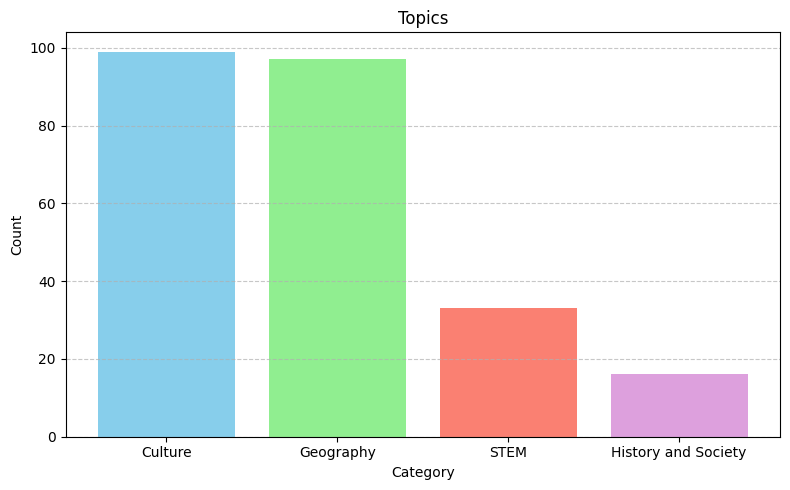

In [6]:
import matplotlib.pyplot as plt
from collections import Counter

data_counter = topic_counter

# Sort the items by count in descending order for a clearer plot
sorted_items = sorted(data_counter.items(), key=lambda item: item[1], reverse=True)
categories = [item[0] for item in sorted_items]
counts = [item[1] for item in sorted_items]

# Create the bar plot
plt.figure(figsize=(8, 5)) # Set a reasonable figure size
plt.bar(categories, counts, color=['skyblue', 'lightgreen', 'salmon', 'plum'])

# Add labels and title
plt.xlabel('Category')
plt.ylabel('Count')
plt.title('Topics')

# Add grid lines for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Ensure labels fit well
plt.tight_layout()


# If you were running this interactively, you might use plt.show()
plt.show()

In [7]:
date_counter

Counter({'2025': 55, '2024': 45})

In [8]:
sources = []
for file in files:
    full_path = os.path.join(input_folder, "step0", file)
    if not os.path.exists(full_path): continue

    with open(full_path) as f:
        data = json.load(f)
    
    sources.append(data["source"])
    if len(sources) == 100: break

In [9]:
count = 0
lang_counter = Counter()
for file in files:
    full_path = os.path.join(input_folder, "step2_1", file)
    if not os.path.exists(full_path): continue

    with open(full_path) as f:
        data = json.load(f)
    
    url_content_mapper = data.get("url_content_mapper")
    if not url_content_mapper: continue

    for _, v in url_content_mapper.items():
        if not v.get("lang"): continue
        lang_counter[v["lang"]] += 1

lang_counter["en"], sum([v for k,v in lang_counter.items() if k != "en"])

(244, 45)

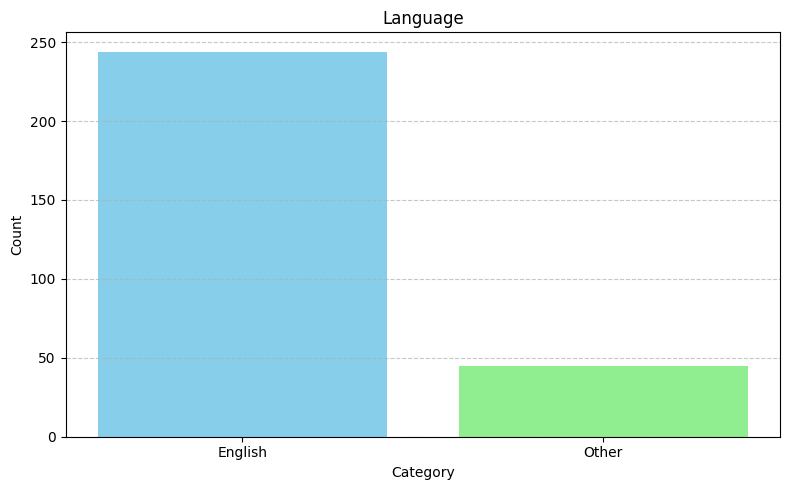

In [10]:
import matplotlib.pyplot as plt
from collections import Counter

data_counter = {"English": lang_counter["en"], "Other": sum([v for k,v in lang_counter.items() if k != "en"])}

# Sort the items by count in descending order for a clearer plot
sorted_items = sorted(data_counter.items(), key=lambda item: item[1], reverse=True)
categories = [item[0] for item in sorted_items]
counts = [item[1] for item in sorted_items]

# Create the bar plot
plt.figure(figsize=(8, 5)) # Set a reasonable figure size
plt.bar(categories, counts, color=['skyblue', 'lightgreen', 'salmon', 'plum'])

# Add labels and title
plt.xlabel('Category')
plt.ylabel('Count')
plt.title('Language')

# Add grid lines for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Ensure labels fit well
plt.tight_layout()


# If you were running this interactively, you might use plt.show()
plt.show()

In [27]:
keypoints_counter = Counter()
numhop_counter = Counter()
with open(os.path.join(input_folder, "step5", "attributes.jsonl")) as f:
    for line in f:
        jline = json.loads(line)
        num_kp = jline["num_keypoints"]
        numhop = jline["num_hops"]

        keypoints_counter[str(num_kp)] += 1

        numhop_counter[str(numhop)] += 1


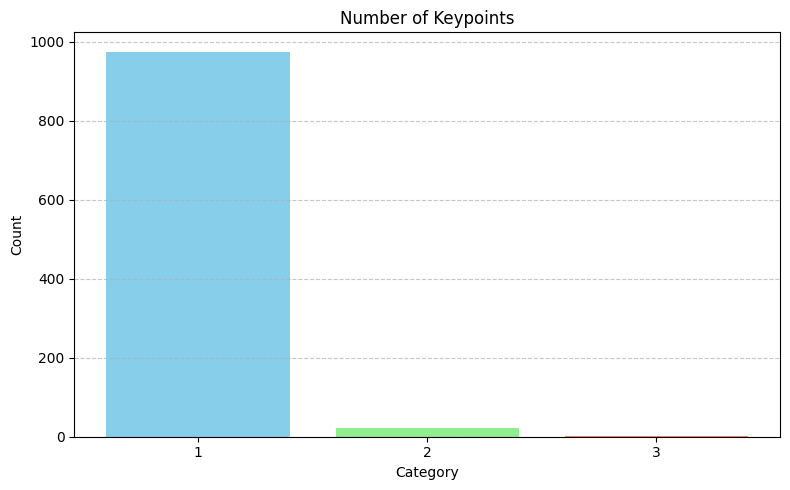

In [28]:
import matplotlib.pyplot as plt
from collections import Counter

data_counter = keypoints_counter

# Sort the items by count in descending order for a clearer plot
sorted_items = sorted(data_counter.items(), key=lambda item: item[1], reverse=True)
categories = [item[0] for item in sorted_items]
counts = [item[1] for item in sorted_items]

# Create the bar plot
plt.figure(figsize=(8, 5)) # Set a reasonable figure size
plt.bar(categories, counts, color=['skyblue', 'lightgreen', 'salmon', 'plum'])

# Add labels and title
plt.xlabel('Category')
plt.ylabel('Count')
plt.title('Number of Keypoints')

# Add grid lines for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Ensure labels fit well
plt.tight_layout()


# If you were running this interactively, you might use plt.show()
plt.show()

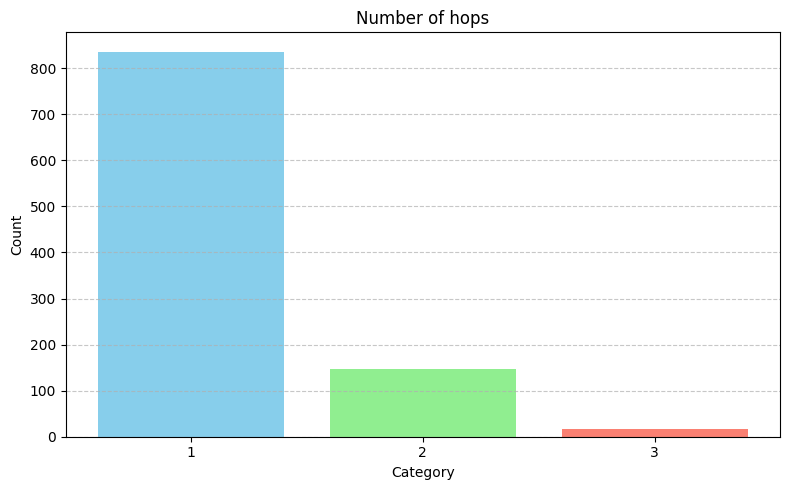

In [29]:
import matplotlib.pyplot as plt
from collections import Counter

data_counter = numhop_counter

# Sort the items by count in descending order for a clearer plot
sorted_items = sorted(data_counter.items(), key=lambda item: item[1], reverse=True)
categories = [item[0] for item in sorted_items]
counts = [item[1] for item in sorted_items]

# Create the bar plot
plt.figure(figsize=(8, 5)) # Set a reasonable figure size
plt.bar(categories, counts, color=['skyblue', 'lightgreen', 'salmon', 'plum'])

# Add labels and title
plt.xlabel('Category')
plt.ylabel('Count')
plt.title('Number of hops')

# Add grid lines for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Ensure labels fit well
plt.tight_layout()


# If you were running this interactively, you might use plt.show()
plt.show()

In [8]:
count = 0
for file in files:
    full_path = os.path.join(input_folder, "step3", file)
    if not os.path.exists(full_path): continue

    with open(full_path) as f:
        data = json.load(f)
    
    if data.get("groundedness_check") and any(data.get("groundedness_check").values()): count += len([item for item in data.get("groundedness_check").values() if item])

In [9]:
count

3456

In [11]:
count = 0
for file in files:
    full_path = os.path.join(input_folder, "step4_extracted_kg", file)
    if not os.path.exists(full_path): continue

    with open(full_path) as f:
        data = json.load(f)
    
    if data.get("fact_kg_mapper"): count += len(data.get("fact_kg_mapper"))

count

180

In [12]:
count = 0
for file in files:
    full_path = os.path.join(input_folder, "step4_generated_question", file)
    if not os.path.exists(full_path): continue

    with open(full_path) as f:
        data = json.load(f)
    
    if data.get("fact_question_mapper"): count += len(data.get("fact_question_mapper"))

count

113

In [13]:
count = 0
for file in files:
    full_path = os.path.join(input_folder, "step4_question_answerability", file)
    if not os.path.exists(full_path): continue

    with open(full_path) as f:
        data = json.load(f)
    
    if data.get("fact_question_mapper"): count += len(data.get("fact_question_mapper"))

count

91

In [14]:
count = 0
for file in files:
    full_path = os.path.join(input_folder, "step4", file)
    if not os.path.exists(full_path): continue

    with open(full_path) as f:
        data = json.load(f)
    
    if data.get("fact_question_mapper"): count += len(data.get("fact_question_mapper"))

count

91

In [14]:
data.get("fact_question_mapper")

{'30': [{'question': "What date did the 2024 Deloitte Top 200 Awards take place, where Nick Mowbray, Mat Mowbray, and Anna Mowbray were recognized as 'visionary leaders of the year'?",
   'num_hops': 1,
   'masked_kg': [{'head': '<Unknown> #1',
     'head_unmasked': 'December 2024',
     'head_type': 'Date',
     'relation': 'is the date of',
     'tail': '2024 Deloitte Top 200 Awards',
     'tail_unmasked': '2024 Deloitte Top 200 Awards',
     'tail_type': 'Event'},
    {'head': 'Nick Mowbray',
     'head_unmasked': 'Nick Mowbray',
     'head_type': 'Person',
     'relation': 'was named',
     'tail': "'visionary leaders of the year'",
     'tail_unmasked': "'visionary leaders of the year'",
     'tail_type': 'Award'},
    {'head': 'Mat Mowbray',
     'head_unmasked': 'Mat Mowbray',
     'head_type': 'Person',
     'relation': 'was named',
     'tail': "'visionary leaders of the year'",
     'tail_unmasked': "'visionary leaders of the year'",
     'tail_type': 'Award'},
    {'head': '

In [2]:
from fast_langdetect import detect as language_detection_func
test = "Die Gesellschaft der \u00c4rzte in Wien verlieh Rudolf-H\u00f6fer-Preis 2015 f\u00fcr die beste nuklearmedizinische Publikation\nHerr Dr. Andreas Hahn von der Universit\u00e4tsklinik f\u00fcr Psychiatrie und Psychotherapie an der Medizinischen Universit\u00e4t Wien wurde im Billrothhaus f\u00fcr seine Publikation \u201eAttenuated serotonin transporter association between dorsal raphe and ventral striatum in major depression\u201c mit dem Rudolf-H\u00f6fer-Preis 2015 ausgezeichnet.\nWien - Am 29. April 2015 wurde in der Gesellschaft der \u00c4rzte in Wien in Anwesenheit von Univ-Prof. Dr. Rudolf H\u00f6fer, dem Begr\u00fcnder und Pionier der Nuklearmedizin in \u00d6sterreich, zum ersten Mal der Rudolf-H\u00f6fer-Preis f\u00fcr die beste Publikation im Zusammenhang mit der \u201eAnwendung radioaktiver Isotope in Klinik und Forschung\u201c in \u00d6sterreich vergeben. Durch den Abend f\u00fchrten der Initiator und Vorsitzende der Jury Herr Univ.-Prof. Dr. Helmut Sinzinger (Insitut ATHOS, Wien) und Herr Univ.-Prof. Dr. Michael Krainer (Univ.-Klinik f\u00fcr Innere Medizin I, MedUni Wien, AKH).\nNach kurzen einleitenden Worten der Moderatoren des Abends wurde der lange Lebensweg von Prof. Dr. Rudolf H\u00f6fer vorgetragen. Anschlie\u00dfend pr\u00e4sentierten die drei im Vorfeld ausgew\u00e4hlten Bewerber, Herr Dr. Andreas Hahn (Univ.-Klinik f\u00fcr Psychiatrie und Psychotherapie, Med Uni Wien, AKH), Herr Ass.-Prof. Priv.-Doz. Dr. Martin Bauer (Univ.-Klinik f\u00fcr Klinische Pharmakologie, Med Uni Wien, AKH) und Herr Mag. Dr. Georg S. Kranz (Univ.-Klinik f\u00fcr Psychiatrie und Psychotherapie, Med Uni Wien, AKH) ihre eingereichten Publikationen.\nNach einer kurzen beeindruckenden Rede des Doyens der Nuklearmedizin in \u00d6sterreich, Herrn Prof. Dr. Rudolf H\u00f6fer, verk\u00fcndete die Jury ihre Entscheidung. Die Arbeit mit dem Titel \u201eAttenuated serotonin transporter association between dorsal raphe and ventral striatum in major depression\u201c von Herrn Dr. Andreas Hahn (Univ.-Klinik f\u00fcr Psychiatrie und Psychotherapie, MedUni Wien, AKH) wurde als beste Publikation ausgezeichnet. Den von der DSD Pharma GesmbH zur Verf\u00fcgung gestellten Rudolf-H\u00f6fer-Preis \u00fcberreichte die Gesch\u00e4ftsf\u00fchrerin Frau Dr. Susanne Dorudi.\nDie Gesellschaft der \u00c4rzte in Wien gratuliert allen Preistr\u00e4gern und bedankt sich beim Sponsor, der Firma DSD Pharma GesmbH sowie Herrn Univ.-Prof. Dr. Rudolf H\u00f6fer, dem der Preis gewidmet ist und bei allen, die ihre Publikation eingereicht haben.\nDie Preistr\u00e4ger im \u00dcberblick:\n1. Preis: Herr Dr. Andreas Hahn (Univ.-Klinik f\u00fcr Psychiatrie und Psychotherapie, Med Uni Wien, AKH) Attenuated serotonin transporter association between dorsal raphe and ventral striatum in major depression, in Human Brain Mapping\n2. Preis: Herr Ass.-Prof. Priv.-Doz. Dr. Martin Bauer (Univ.-Klinik f\u00fcr Klinische Pharmakologie, Med Uni Wien, AKH) In vivo P-glycoprotein function before and after epilepsy surger, in Neurology\n3. Preis: Herr Mag. Dr. Georg S. Kranz (Univ.-Klinik f\u00fcr Psychiatrie und Psychotherapie, Med Uni Wien, AKH) High-dose testosterone treatment increases serotonin transporter binding in transgender people, in Biological Psychiatry"

In [ ]:
language_detection_func(test, )

[{'lang': 'de', 'score': 0.9601981043815613}]

In [4]:
from fast_langdetect import LangDetectConfig, LangDetector

config = LangDetectConfig(max_input_length=256)
detector = LangDetector(config)

In [5]:
detector.detect(test)

[{'lang': 'de', 'score': 0.9894468784332275}]